# Análisis de cambio semánticos

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [3]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") + '/muerte_subita/' # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_808811150/'
pd.set_option('display.max_colwidth', None)

Se selecciona para analizar el modelo de procrustes

In [5]:
basename = 'procrustes'
iteracion = 50
tam_vector = 80

In [6]:
# estabilidad_procrustes_iter10_tam50
selected_topics_df = pd.read_csv(
    modelo_dir+'/estabilidad_procrustes/estabilidad_'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv',
    converters={'par_periodo': literal_eval})

selected_topics_df.head(5)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,top10_vecindad_t1,top10_vecindad_t2
0,16,"(2009, 2014)",proyecto,0.690310,17,"[('salud', 0.9823289513587952), ('persona', 0.9607980251312256), ('paro', 0.9006549119949341), ('lugar', 0.9005680680274963), ('centro', 0.9005435109138489), ('privado', 0.8947027921676636), ('dea', 0.872826874256134), ('evento', 0.8461856245994568), ('cardiaco', 0.8322585225105286), ('caso', 0.8233528733253479)]","[('articulo', 0.9491197466850281), ('deber', 0.7432569265365601), ('forma', 0.7293074727058411), ('salud', 0.6228327751159668), ('tratamiento', 0.6161350011825562), ('centro', 0.6078642010688782), ('publico', 0.5712985992431641), ('ley', 0.5621874928474426), ('causa', 0.5522525310516357), ('automatico', 0.5341042876243591)]"
1,36,"(2009, 2014)",proyecto,0.726092,17,"[('persona', 0.980424702167511), ('salud', 0.963733434677124), ('privado', 0.8859602808952332), ('espacio', 0.8795743584632874), ('lugar', 0.8704620003700256), ('paro', 0.8701701164245605), ('centro', 0.8372939229011536), ('dea', 0.811508059501648), ('deber', 0.8059856295585632), ('caso', 0.8051305413246155)]","[('articulo', 0.9392008781433105), ('forma', 0.7887793779373169), ('deber', 0.6991502642631531), ('causa', 0.6742412447929382), ('publico', 0.6556886434555054), ('tratamiento', 0.6457445621490479), ('centro', 0.6192220449447632), ('automatico', 0.596928060054779), ('muerte', 0.5651697516441345), ('ley', 0.5574283003807068)]"
2,25,"(2009, 2014)",proyecto,0.731756,17,"[('salud', 0.9752298593521118), ('persona', 0.9601513743400574), ('lugar', 0.8944293260574341), ('ley', 0.8684065341949463), ('privado', 0.8424566388130188), ('espacio', 0.8345298767089844), ('dea', 0.8225423097610474), ('paro', 0.8222349286079407), ('centro', 0.8163573741912842), ('cardiaco', 0.7889621257781982)]","[('articulo', 0.9471457004547119), ('deber', 0.8221127986907959), ('forma', 0.7875797152519226), ('centro', 0.674140214920044), ('salud', 0.6024944186210632), ('publico', 0.5953723192214966), ('ley', 0.5746527910232544), ('tratamiento', 0.570735514163971), ('causa', 0.5707321763038635), ('automatico', 0.5045754313468933)]"
3,15,"(2009, 2014)",proyecto,0.734176,17,"[('salud', 0.9678667783737183), ('persona', 0.9557119607925415), ('lugar', 0.9003921151161194), ('espacio', 0.8761389255523682), ('privado', 0.8700663447380066), ('dea', 0.8503977656364441), ('centro', 0.8345492482185364), ('paro', 0.831306517124176), ('evento', 0.8143526315689087), ('resucitacion', 0.7769882678985596)]","[('articulo', 0.9810120463371277), ('forma', 0.7909393310546875), ('centro', 0.7600632905960083), ('publico', 0.6862596273422241), ('deber', 0.6533908843994141), ('tratamiento', 0.618094801902771), ('causa', 0.5987719893455505), ('ley', 0.5816642045974731), ('automatico', 0.5707556009292603), ('muerte', 0.5628571510314941)]"
4,0,"(2009, 2014)",proyecto,0.735110,17,"[('persona', 0.9790372252464294), ('salud', 0.941186249256134), ('espacio', 0.8848987221717834), ('ley', 0.878856897354126), ('deber', 0.8593773245811462), ('lugar', 0.8549385666847229), ('caso', 0.8449698686599731), ('dea', 0.8434907793998718), ('paro', 0.8364255428314209), ('centro', 0.8312652707099915)]","[('articulo', 0.9652698636054993), ('forma', 0.792607307434082), ('deber', 0.6740540862083435), ('centro', 0.6556524038314819), ('publico', 0.6479352116584778), ('tratamiento', 0.6211487054824829), ('ley', 0.5775884985923767), ('automatico', 0.5665280818939209), ('muerte', 0.5348447561264038), ('causa', 0.5306683778762817)]"


In [ ]:
selected_topics_df.describe() # Estadística

In [24]:
n = 25
at_least_in_any_decade = 5
pares_periodo = [ (2009, 2014),(2014, 2019)]
topn_periodo = {}

for par_periodo in pares_periodo:
    df =  selected_topics_df[
        selected_topics_df['par_periodo'] == par_periodo
    ].copy()
    
    
    frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
    frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
    frecPer1.columns = ['palabra', 'frec1', 'porc1']
    frecPer2.columns = ['palabra', 'frec2', 'porc2']
    #print(frecPer2.shape)
    topn_all_df = []

    for iter in range(iteracion):
        #print(iter)
        df_topn = df[(df.iteracion==iter)]
        #controlar frec
        #display(df_topn)
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn.sort_values('similaridad_semantica', ascending=True).head(n)
        #display(df_topn)
        topn_all_df.append(df_topn)
    
    topn_periodo[par_periodo] = pd.concat(topn_all_df, ignore_index=True)    


#### Intersección promedio
Por el enfoque Procruste para cada par de periodos de 5 años:
¿Cuál es la intersección promedio de los top 300 palabras entre las 50 ejecuciones para cada par de periodos comparados con intervalos de confianza del 95% calculados mediante el método bootstrap? 


In [25]:
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95)
    return (res.confidence_interval.low, res.confidence_interval.high)

In [26]:
topn_periodo_all = topn_periodo.copy() # copiar

In [27]:
for par_periodo in pares_periodo: 
    display(topn_periodo[par_periodo].shape)
    df = topn_periodo[par_periodo].copy()
    data = df['palabra'].value_counts().reset_index()
    data = data[data['count']>2]
    pal_lista = list(data['palabra'].unique())
    df = df[df['palabra'].isin(pal_lista)]
    df = df[['par_periodo', 'palabra', 'similaridad_semantica']].groupby(['par_periodo', 'palabra']).agg(['mean', confidence_intervals]).reset_index()
    #df.sort_values(by='par_periodo', inplace=True)
    df.columns = [
    '_'.join(filter(None, x))
    for x in df.columns.to_flat_index() 
    ]
    topn_periodo[par_periodo] = df

    
  
  


(850, 8)

(500, 8)

Top 10 palabras 

De los top 25 palabras con más de 5 veces de ocurrencia en alguno de pareas de períodos comparados.

* si Distancia = 1 - similitud coseno (sc)


Interpretación
* dist ~ 0.0 (sc ~ 1)	 La palabra no cambió su significado
* dist ~ 0.5 (sc ~ 0.5)  Cambio moderado
* dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)

In [28]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title + " Top "+str(top))
    plt.show()



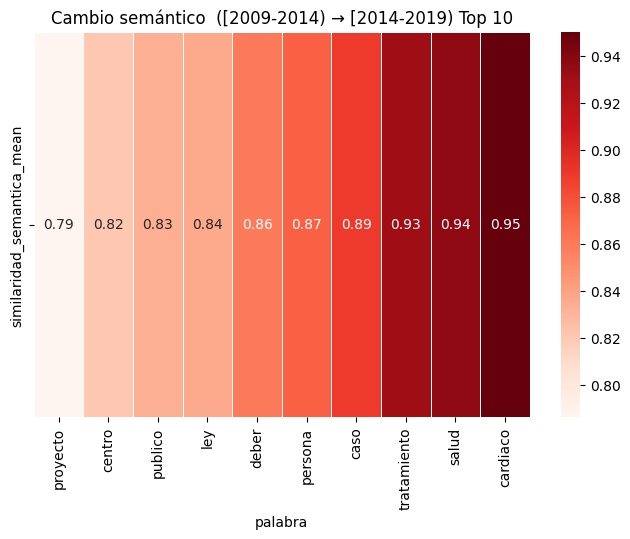

TOP 10 Palabras: ['proyecto' 'centro' 'publico' 'ley' 'deber' 'persona' 'caso'
 'tratamiento' 'salud' 'cardiaco']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
13,"(2009, 2014)",proyecto,0.786296,"(0.7757281813096584, 0.7959792794018206)"
5,"(2009, 2014)",centro,0.820601,"(0.8139981457745249, 0.8271542884831687)"
14,"(2009, 2014)",publico,0.833313,"(0.8248717289280115, 0.8411216399058848)"
10,"(2009, 2014)",ley,0.836744,"(0.8282613367530904, 0.8447807167025535)"
6,"(2009, 2014)",deber,0.860219,"(0.8504872487432164, 0.8696133232689488)"
12,"(2009, 2014)",persona,0.872056,"(0.8637621578345746, 0.8790911237505117)"
3,"(2009, 2014)",caso,0.888765,"(0.8836221848448486, 0.8942562496689385)"
16,"(2009, 2014)",tratamiento,0.931386,"(0.92716268445648, 0.9354393190727159)"
15,"(2009, 2014)",salud,0.937041,"(0.9317057275458711, 0.9420150666436893)"
2,"(2009, 2014)",cardiaco,0.950051,"(0.9455871222620712, 0.9542776776198314)"


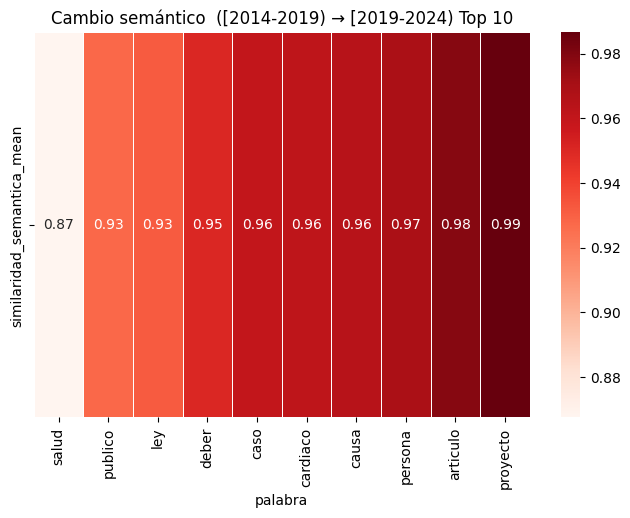

TOP 10 Palabras: ['salud' 'publico' 'ley' 'deber' 'caso' 'cardiaco' 'causa' 'persona'
 'articulo' 'proyecto']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
9,"(2014, 2019)",salud,0.867438,"(0.8600291065561562, 0.8744933497112365)"
8,"(2014, 2019)",publico,0.927672,"(0.9231054963829868, 0.9321579866482873)"
5,"(2014, 2019)",ley,0.931983,"(0.9263125777708319, 0.9364411234563876)"
4,"(2014, 2019)",deber,0.950620,"(0.9461728207121146, 0.9547314043001579)"
2,"(2014, 2019)",caso,0.960090,"(0.955693519180075, 0.9638270892003764)"
1,"(2014, 2019)",cardiaco,0.961861,"(0.9574587187508182, 0.9656781461856453)"
3,"(2014, 2019)",causa,0.964554,"(0.9618066113794342, 0.9670521759581816)"
6,"(2014, 2019)",persona,0.968873,"(0.9644171412997965, 0.9724958789873107)"
0,"(2014, 2019)",articulo,0.978672,"(0.97643412814417, 0.9807999775423897)"
7,"(2014, 2019)",proyecto,0.986524,"(0.9844122552098972, 0.9882673254572575)"


In [12]:
topk = 10
for par_periodo in pares_periodo:

    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    # Graficar Heatmaps
    plot_heatmap(df[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", df['palabra'].unique())
    display(df)    


Palabras comunes entre los pares de períodos

In [13]:
# palabra común en entre períodos
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 10


Top 10

In [14]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014']
# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019']
# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019']]
print("Top 10 de palabras comunes con mayor cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df.sort_values('ss_mean_2009_2014').head(10)['palabra'].unique() )
display(df.sort_values('ss_mean_2009_2014').head(10))

Top 10 de palabras comunes con mayor cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: ['proyecto' 'publico' 'ley' 'deber' 'persona' 'caso' 'salud' 'cardiaco'
 'articulo' 'causa']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019
7,proyecto,0.786296,0.986524,"(0.7757281813096584, 0.7959792794018206)","(0.9844122552098972, 0.9882673254572575)"
8,publico,0.833313,0.927672,"(0.8248717289280115, 0.8411216399058848)","(0.9231054963829868, 0.9321579866482873)"
5,ley,0.836744,0.931983,"(0.8282613367530904, 0.8447807167025535)","(0.9263125777708319, 0.9364411234563876)"
4,deber,0.860219,0.950620,"(0.8504872487432164, 0.8696133232689488)","(0.9461728207121146, 0.9547314043001579)"
6,persona,0.872056,0.968873,"(0.8637621578345746, 0.8790911237505117)","(0.9644171412997965, 0.9724958789873107)"
2,caso,0.888765,0.960090,"(0.8836221848448486, 0.8942562496689385)","(0.955693519180075, 0.9638270892003764)"
9,salud,0.937041,0.867438,"(0.9317057275458711, 0.9420150666436893)","(0.8600291065561562, 0.8744933497112365)"
1,cardiaco,0.950051,0.961861,"(0.9455871222620712, 0.9542776776198314)","(0.9574587187508182, 0.9656781461856453)"
0,articulo,0.960919,0.978672,"(0.9568297752286204, 0.9643578128637375)","(0.97643412814417, 0.9807999775423897)"
3,causa,0.980123,0.964554,"(0.9770455623577735, 0.9825714241735872)","(0.9618066113794342, 0.9670521759581816)"


In [15]:
print("Top 10 de palabras comunes con mayor cambio semántco entre Período [2014, 2019) - > [2019, 2024)  ")
print("Palabras:",df.sort_values('ss_mean_2014_2019').head(10)['palabra'].unique() )
display(df.sort_values('ss_mean_2014_2019').head(10))

Top 10 de palabras comunes con mayor cambio semántco entre Período [2014, 2019) - > [2019, 2024)  
Palabras: ['salud' 'publico' 'ley' 'deber' 'caso' 'cardiaco' 'causa' 'persona'
 'articulo' 'proyecto']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019
9,salud,0.937041,0.867438,"(0.9317057275458711, 0.9420150666436893)","(0.8600291065561562, 0.8744933497112365)"
8,publico,0.833313,0.927672,"(0.8248717289280115, 0.8411216399058848)","(0.9231054963829868, 0.9321579866482873)"
5,ley,0.836744,0.931983,"(0.8282613367530904, 0.8447807167025535)","(0.9263125777708319, 0.9364411234563876)"
4,deber,0.860219,0.950620,"(0.8504872487432164, 0.8696133232689488)","(0.9461728207121146, 0.9547314043001579)"
2,caso,0.888765,0.960090,"(0.8836221848448486, 0.8942562496689385)","(0.955693519180075, 0.9638270892003764)"
1,cardiaco,0.950051,0.961861,"(0.9455871222620712, 0.9542776776198314)","(0.9574587187508182, 0.9656781461856453)"
3,causa,0.980123,0.964554,"(0.9770455623577735, 0.9825714241735872)","(0.9618066113794342, 0.9670521759581816)"
6,persona,0.872056,0.968873,"(0.8637621578345746, 0.8790911237505117)","(0.9644171412997965, 0.9724958789873107)"
0,articulo,0.960919,0.978672,"(0.9568297752286204, 0.9643578128637375)","(0.97643412814417, 0.9807999775423897)"
7,proyecto,0.786296,0.986524,"(0.7757281813096584, 0.7959792794018206)","(0.9844122552098972, 0.9882673254572575)"


In [16]:
# GUARDAR OBJETO
with open(modelo_dir+'/palComun_cambioSem_procrustes_df.pkl', 'wb') as file: 
    pickle.dump(df,file)

In [17]:
# Palabras en común
df.palabra.unique()

array(['articulo', 'cardiaco', 'caso', 'causa', 'deber', 'ley', 'persona',
       'proyecto', 'publico', 'salud'], dtype=object)

Buscando palabras asociadas a "muerte súbita"

In [18]:
ms_lista = ["emergencia","desfibrilador", "cardiovascular","rcp","subita"]
for palabra in ms_lista:
    for par_periodo in pares_periodo:
        
        df = topn_periodo[par_periodo]
        busqueda = df[df['palabra'].str.contains(palabra)]
        if (len(busqueda)>0):
            print(par_periodo)
            display(busqueda)

(2009, 2014)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals
8,"(2009, 2014)",desfibrilador,0.972132,"(0.9702272778780068, 0.9741464054484884)"


### Visualizaciones

t-SNE (t-distributed Stochastic Neighbor Embedding) es un algoritmo de reducción de dimensionalidad que:

Preserva las relaciones locales entre los vectores (es decir, quién está cerca de quién).

No preserva distancias globales ni direcciones.


In [36]:
## 2. Visualización del desplazamiento con t-SNE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Función para reducir dimensiones con t-SNE
def reducir_dimensionalidad(embeddings, n_components=2, perplexity=5):
    words = list(embeddings.keys())
    vectors = np.array([embeddings[word] for word in words])
    
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return words, reduced_vectors

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors


# Función para visualizar cambio semántico
def plot_word_shifts(words, m1, m2, vecs1, vecs2, pares, title="Cambio semántico"):
    plt.figure(figsize=(15, 10),tight_layout=True)
    
    for i, word in enumerate(words):
        dist = 1 - compute_cosine_similarity(m1,m2,word)

        plt.scatter(vecs1[i, 0], vecs1[i, 1], color='blue', alpha=0.6)
        plt.scatter(vecs2[i, 0], vecs2[i, 1], color='red', alpha=0.6)
        plt.plot([vecs1[i, 0], vecs2[i, 0]], [vecs1[i, 1], vecs2[i, 1]], color='gray', alpha=0.5)
        plt.text(vecs2[i, 0], vecs2[i, 1], f"{word}\n∆={dist:.2f}", fontsize=9,color='black',ha="left")
        

    
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.title(title,fontsize=20)
    plt.legend([pares[0], pares[1],"Desplazamiento 1−similitud coseno"])
    #plt.tight_layout()
    #plt.subplots_adjust(left=0.2, right=0.5)

    plt.show()

In [38]:
def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

In [39]:
# Crear directorio para algoritmo de cambio semántico
# Crear directorio modelo alineado
alin_dir = modelo_dir +'/estabilidad_procrustes/alineado/'
iter = 0

In [40]:
# modelos alineados por procuster para iter 0
m_2009 = Word2Vec.load(alin_dir+"alin_" + str(2009)+'_'+str(iter)+'.mdl')
m_2014 = Word2Vec.load(alin_dir+"alin_" + str(2014)+'_'+str(iter)+'.mdl') 
m_2019 = Word2Vec.load(alin_dir+"alin_" + str(2019)+'_'+str(iter)+'.mdl')   

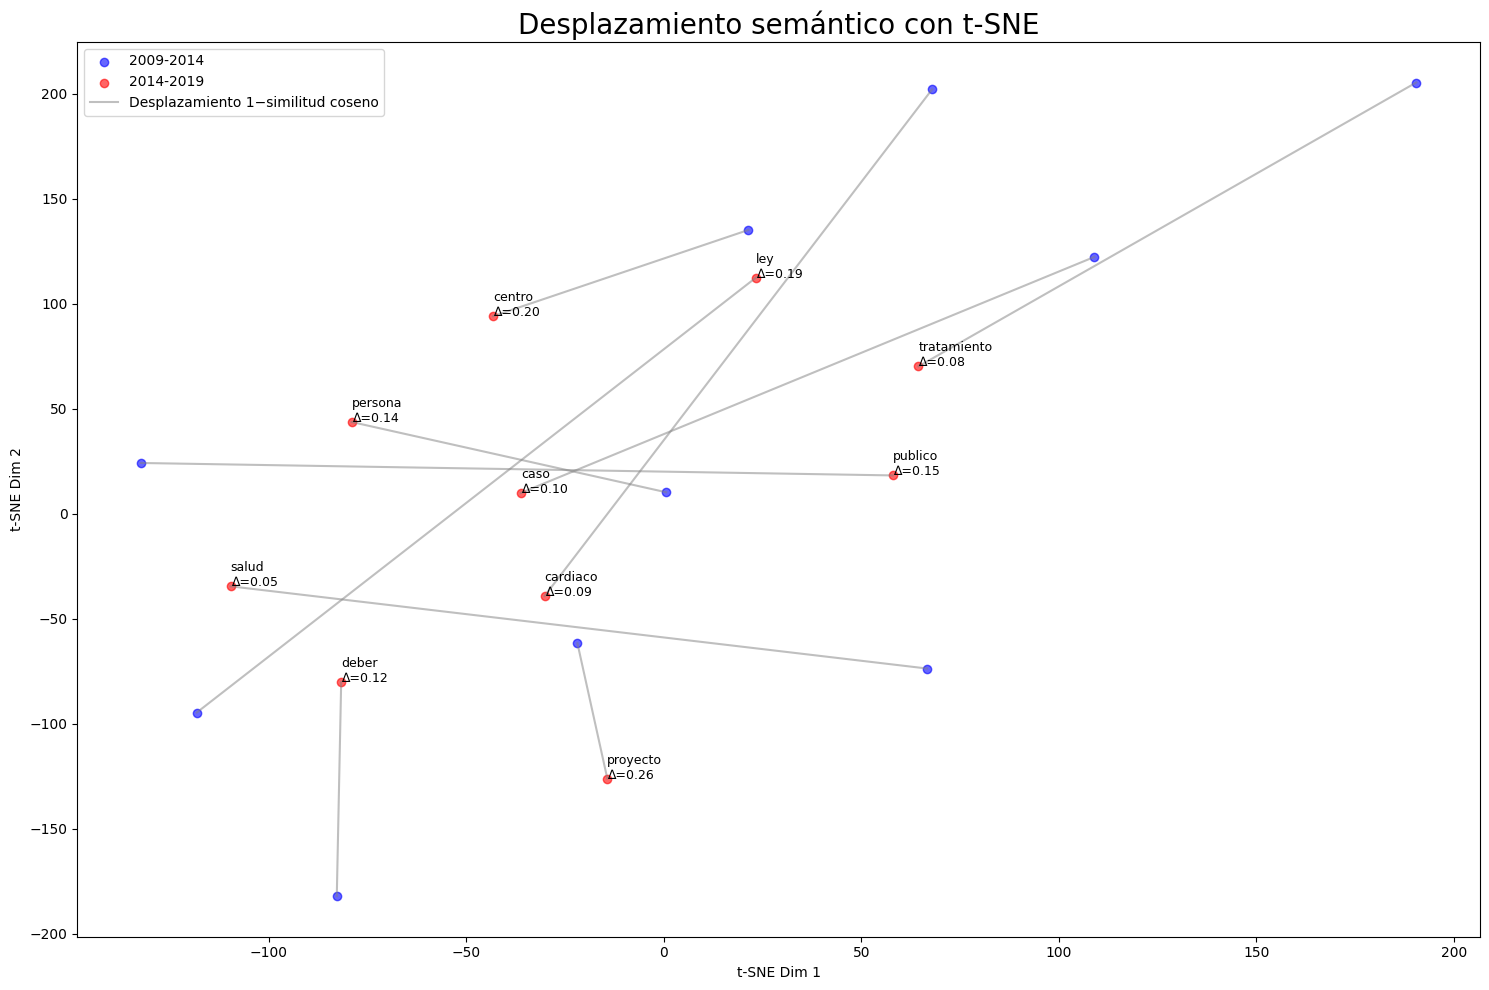

In [41]:
palabrasmc_2009_2014 = ['proyecto', 'centro' ,'publico' ,'ley', 'deber' ,'persona' ,'caso',
 'tratamiento' ,'salud' ,'cardiaco']
# Reducir dimensiones para los períodos alineados
vecs_1 = reducir_dimensionalidad(m_2009, palabrasComun = palabrasmc_2009_2014 ) 
vecs_2 = reducir_dimensionalidad(m_2014, palabrasComun = palabrasmc_2009_2014 )
# Graficar cambios semánticos en palabras clave
titulo = "Desplazamiento semántico con t-SNE"
plot_word_shifts(palabrasmc_2009_2014,m_2009,m_2014, vecs_1, vecs_2, ('2009-2014','2014-2019'),titulo)  


No interpretar literalmente las distancias o direcciones en t-SNE (porque puede reordenar todo en 2D).
* Azul: Ubicación de la palabra en el primer período.
* Rojo: Ubicación en el segundo período.
* Línea gris: Movimiento del significado de la palabra.

In [42]:
periodo_df = topn_periodo_all[(2009,2014)]
periodo_df = periodo_df[periodo_df.iteracion==0]
periodo_df = periodo_df[periodo_df['palabra'].isin(palabrasmc_2009_2014)][['palabra','similaridad_semantica','top10_vecindad_t1','top10_vecindad_t2']]
periodo_df['vt1'] = periodo_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df['vt2'] = periodo_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df[['palabra','similaridad_semantica','vt1','vt2']]

,palabra,similaridad_semantica,vt1,vt2
0,proyecto,0.735110,"[persona, salud, espacio, ley, deber, lugar, caso, dea, paro, centro]","[articulo, forma, deber, centro, publico, tratamiento, ley, automatico, muerte, causa]"
1,centro,0.797752,"[cardiaco, corazon, caso, paro, persona, proyecto, tratamiento, enfermedad, desfibrilador, muerte]","[ley, forma, persona, automatico, tratamiento, articulo, causa, desfibrilador, proyecto, publico]"
2,ley,0.814739,"[articulo, espacio, deber, forma, resucitacion, proyecto, persona, publico, acceso, dea]","[tratamiento, automatico, centro, desfibrilador, forma, persona, publico, desfibrilacion, articulo, proyecto]"
3,publico,0.848667,"[evento, maniobra, privado, externo, dea, acceso, resucitacion, desfibrilacion, automatico, lugar]","[desfibrilacion, desfibrilador, tratamiento, automatico, forma, caso, muerte, ley, cardiaco, proyecto]"
4,persona,0.861891,"[proyecto, salud, centro, paro, caso, cardiaco, ley, corazon, lugar, evento]","[caso, salud, centro, ley, cardiaco, desfibrilador, causa, automatico, tratamiento, forma]"
5,deber,0.876636,"[articulo, espacio, ley, proyecto, resucitacion, forma, dea, persona, salud, acceso]","[salud, cardiaco, proyecto, forma, caso, publico, causa, articulo, muerte, persona]"
6,caso,0.895996,"[cardiaco, centro, muerte, enfermedad, corazon, persona, causa, forma, proyecto, tratamiento]","[persona, cardiaco, desfibrilacion, publico, desfibrilador, automatico, tratamiento, muerte, forma, salud]"
7,cardiaco,0.912446,"[centro, caso, corazon, paro, persona, enfermedad, muerte, causa, proyecto, tratamiento]","[caso, causa, muerte, forma, deber, publico, salud, persona, desfibrilacion, centro]"
8,tratamiento,0.919109,"[desfibrilador, automatico, desfibrilacion, caso, corazon, centro, cardiaco, forma, muerte, externo]","[automatico, desfibrilador, publico, desfibrilacion, ley, forma, centro, caso, muerte, proyecto]"
10,salud,0.946689,"[lugar, proyecto, persona, dea, paro, privado, espacio, evento, resucitacion, publico]","[deber, persona, caso, cardiaco, causa, centro, forma, proyecto, publico, ley]"


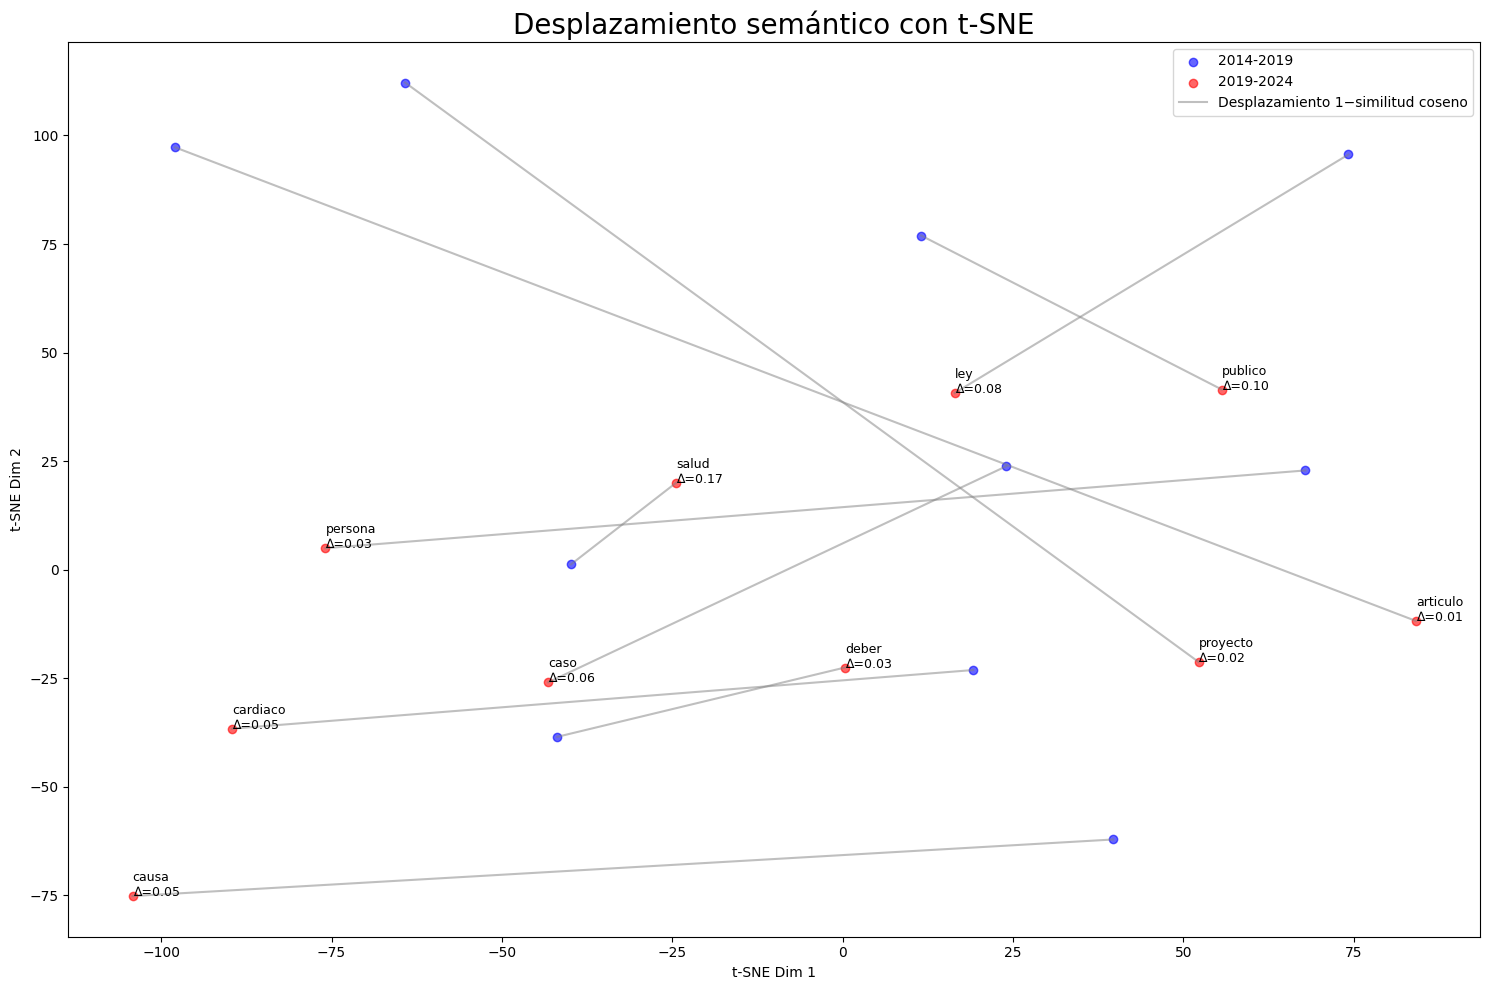

In [43]:
palabrasmc_2014_2019 = ['salud', 'publico' ,'ley', 'deber', 'caso' ,'cardiaco', 'causa' ,'persona', 'articulo', 'proyecto']
# Reducir dimensiones para los períodos alineados
vecs_1 = reducir_dimensionalidad(m_2014, palabrasComun = palabrasmc_2014_2019 ) 
vecs_2 = reducir_dimensionalidad(m_2019, palabrasComun = palabrasmc_2014_2019 )
titulo = "Desplazamiento semántico con t-SNE"
plot_word_shifts(palabrasmc_2014_2019,m_2014,m_2019, vecs_1, vecs_2, ('2014-2019','2019-2024'),titulo)  


In [44]:
periodo_df = topn_periodo_all[(2014,2019)]
periodo_df = periodo_df[periodo_df.iteracion==0]
periodo_df = periodo_df[periodo_df['palabra'].isin(palabrasmc_2014_2019)][['palabra','similaridad_semantica','top10_vecindad_t1','top10_vecindad_t2']]
periodo_df['vt1'] = periodo_df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df['vt2'] = periodo_df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
periodo_df[['palabra','similaridad_semantica','vt1','vt2']]

,palabra,similaridad_semantica,vt1,vt2
0,salud,0.832533,"[deber, persona, caso, cardiaco, causa, centro, forma, proyecto, publico, ley]","[ley, persona, caso, deber, publico, proyecto, cardiaco, articulo, causa]"
1,publico,0.904617,"[desfibrilacion, desfibrilador, tratamiento, automatico, forma, caso, muerte, ley, cardiaco, proyecto]","[ley, proyecto, articulo, deber, salud, caso, persona, causa, cardiaco]"
2,ley,0.918286,"[tratamiento, automatico, centro, desfibrilador, forma, persona, publico, desfibrilacion, articulo, proyecto]","[publico, salud, deber, proyecto, articulo, persona, caso, cardiaco, causa]"
3,caso,0.942506,"[persona, cardiaco, desfibrilacion, publico, desfibrilador, automatico, tratamiento, muerte, forma, salud]","[salud, persona, deber, cardiaco, ley, publico, causa, proyecto, articulo]"
4,cardiaco,0.948968,"[caso, causa, muerte, forma, deber, publico, salud, persona, desfibrilacion, centro]","[causa, persona, caso, deber, salud, proyecto, articulo, ley, publico]"
5,causa,0.950229,"[muerte, forma, cardiaco, centro, caso, persona, deber, articulo, proyecto, salud]","[cardiaco, proyecto, persona, articulo, deber, caso, publico, salud, ley]"
6,deber,0.973853,"[salud, cardiaco, proyecto, forma, caso, publico, causa, articulo, muerte, persona]","[caso, salud, proyecto, ley, publico, articulo, cardiaco, persona, causa]"
7,persona,0.974199,"[caso, salud, centro, ley, cardiaco, desfibrilador, causa, automatico, tratamiento, forma]","[salud, cardiaco, caso, causa, ley, deber, proyecto, publico, articulo]"
8,proyecto,0.979361,"[articulo, forma, deber, centro, publico, tratamiento, ley, automatico, muerte, causa]","[articulo, publico, deber, ley, causa, salud, cardiaco, persona, caso]"
9,articulo,0.992581,"[proyecto, forma, centro, ley, deber, tratamiento, causa, publico, automatico, muerte]","[proyecto, publico, ley, deber, causa, salud, cardiaco, persona, caso]"


#### Vecindades

In [45]:
## 3. Visualización de vecindades semánticas

def plot_neighbors_tsne(word, embeddings_by_period, alineados,periods, top_k=10):
    all_vectors = []
    all_labels = []
    all_colors = []
    center_coords = {}
    legend_labels = []

    color_map = plt.cm.get_cmap("tab10", len(periods))

    for i, period in enumerate(periods):
        if word not in embeddings_by_period[period]:
            print(f" '{word}' no está en el vocabulario del período {period}")
            continue
        
        center_vec = embeddings_by_period[period][word]
        vocab = embeddings_by_period[period]

   

        palabras_masSim = alineados[period].wv.most_similar(positive=[word], topn=top_k)
        neighbors = [ pal_peso[0] for pal_peso in palabras_masSim]
        #palabras_masSim_period1 = m2.wv.most_similar(positive=[palabra], topn=top_k)
        #neighbors = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_k]

        # Agregar el centro y sus vecinos
        all_vectors.append(center_vec)
        all_labels.append(word)  # No mostrar periodo en texto
        all_colors.append(i)
        legend_labels.append((period, period+5))

        for neighbor in neighbors:
            all_vectors.append(vocab[neighbor])
            all_labels.append(neighbor)  # Solo mostrar nombre del vecino
            all_colors.append(i)
            legend_labels.append((period, period+5))

    if not all_vectors:
        print("No hay datos suficientes para graficar.")
        return

    X = np.array(all_vectors)
    tsne = TSNE(n_components=2, perplexity=5
                , random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(15, 10))
    scatter_handles = {}
    idx = 0
    for i, period in enumerate(periods):
        if (period, period+5) not in legend_labels:
            continue
        color = color_map(i)
        etiqueta = "["+str(period)+","+str(period+5)+")"
        handle = plt.scatter([], [], color=color, label=etiqueta)
        scatter_handles[period] = handle

    max_dist = -1
    max_pair = None

    for i, (x, label) in enumerate(zip(X_2d, all_labels)):
        color = color_map(all_colors[i])
        period = legend_labels[i]
        plt.scatter(x[0], x[1], color=color, s=60)
        if label != word:
            plt.text(x[0], x[1], label, fontsize=9)
        else:
            # es el centro, guardar la coordenada
            plt.text(x[0], x[1], label, fontsize=10, color='blue')

   
    plt.title("Vecindades semánticas (top "+str(top_k)+") para "+word)
   
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(modelo_dir+'/estabilidad_procrustes/estabilidad_procrustes_'+word)

    plt.show()



In [46]:
# Para graficar
embeddings_by_period = {}
alineados = {}
base = 2009
vocab = {}
for modelo in [m_2009,m_2014,m_2019]:
    for word in modelo.wv.key_to_index:
        vocab[word] = modelo.wv.get_vector(word)
    embeddings_by_period[base]=  vocab
    alineados[base] = modelo
    base = base + 5

embeddings_by_period[2009]

{'dea': array([ 2.50708759e-01, -1.59308672e-01, -1.69303551e-01, -1.41576126e-01,
         1.29344454e-02,  1.44657388e-01, -2.53284067e-01,  5.75320497e-02,
         3.39284241e-02,  3.07715945e-02, -1.28582820e-01,  1.21017702e-01,
         1.32163823e-01,  8.47947225e-02,  1.22666962e-01,  3.50277007e-01,
         9.79388729e-02, -2.53411084e-01, -5.24713807e-02,  2.43742123e-01,
         2.76149750e-01,  4.69527580e-03,  3.06086719e-01, -3.57262716e-02,
         2.45597780e-01,  1.14552736e-01, -2.62501985e-01,  7.58669048e-04,
         7.57035688e-02,  1.52127668e-01,  9.28494558e-02, -6.41341805e-02,
         1.97691159e-04,  6.36015013e-02, -1.17922172e-01,  2.27041200e-01,
        -9.54725146e-02,  2.96810716e-01, -1.57308549e-01,  1.71066761e-01,
        -5.72275221e-02,  2.53364705e-02, -1.17233910e-01, -1.97255999e-01,
        -4.11899388e-02,  9.58653688e-02,  1.37742862e-01, -1.40510708e-01,
         1.43039431e-02,  8.22563618e-02, -5.11338897e-02, -5.08651920e-02,
     

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23272\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


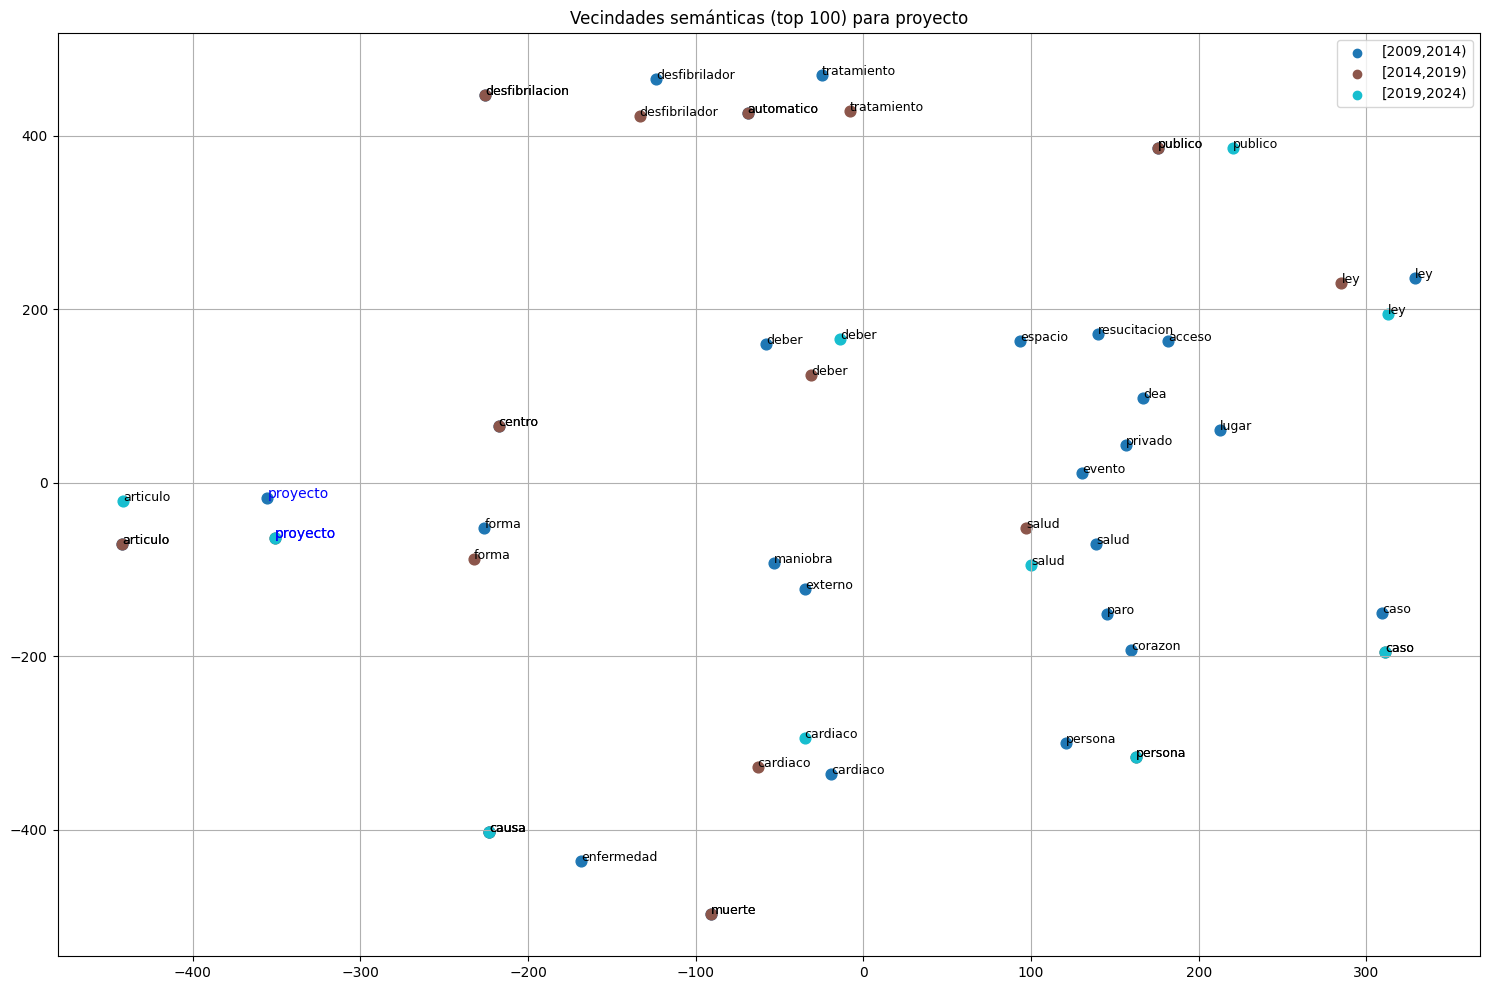

In [55]:
plot_neighbors_tsne('proyecto', embeddings_by_period,alineados, [2009,2014,2019], top_k=100)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_23272\3491657529.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


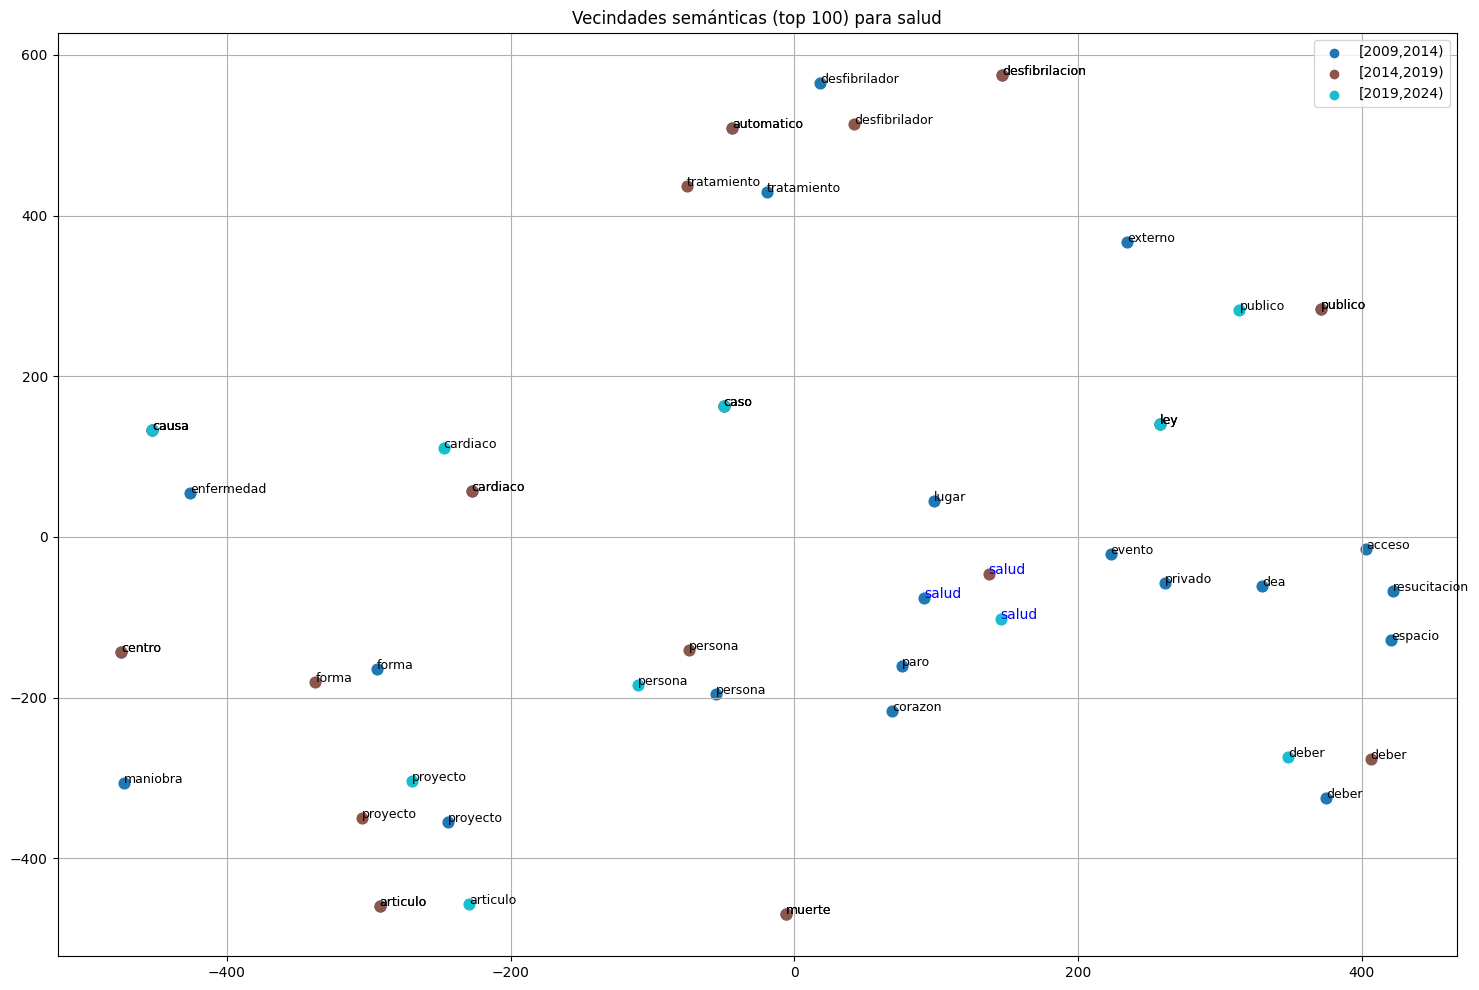

In [54]:

plot_neighbors_tsne('salud', embeddings_by_period,alineados, [2009,2014,2019], top_k=100)
